##Unveiling the android app market(Google play store Analysis)

1.Load Datasets

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

In [ ]:
apps = pd.read_csv("googleplaystore.csv")
reviews = pd.read_csv("googleplaystore_user_reviews.csv")

In [ ]:
apps.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [ ]:
apps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [ ]:
apps.isnull().sum()

,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


2.Data Cleaning

In [ ]:
# Remove duplicates

apps = apps.drop_duplicates()
reviews = reviews.drop_duplicates()

In [ ]:
#clean install
apps["Installs"] = apps["Installs"].str.replace(",", "")
apps["Installs"] = apps["Installs"].str.replace("+", "")
apps["Installs"] = pd.to_numeric(apps["Installs"],errors="coerce")

In [ ]:
#clean price
apps["Price"]=apps["Price"].astype(str).str.replace("$","",regex=False)
apps["Price"]=pd.to_numeric(apps["Price"],errors="coerce")

In [ ]:
apps

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000.0,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000.0,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50000000.0,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,100000.0,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,5000.0,Free,0.0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100.0,Free,0.0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,1000.0,Free,0.0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,1000.0,Free,0.0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


###3.Category analysis

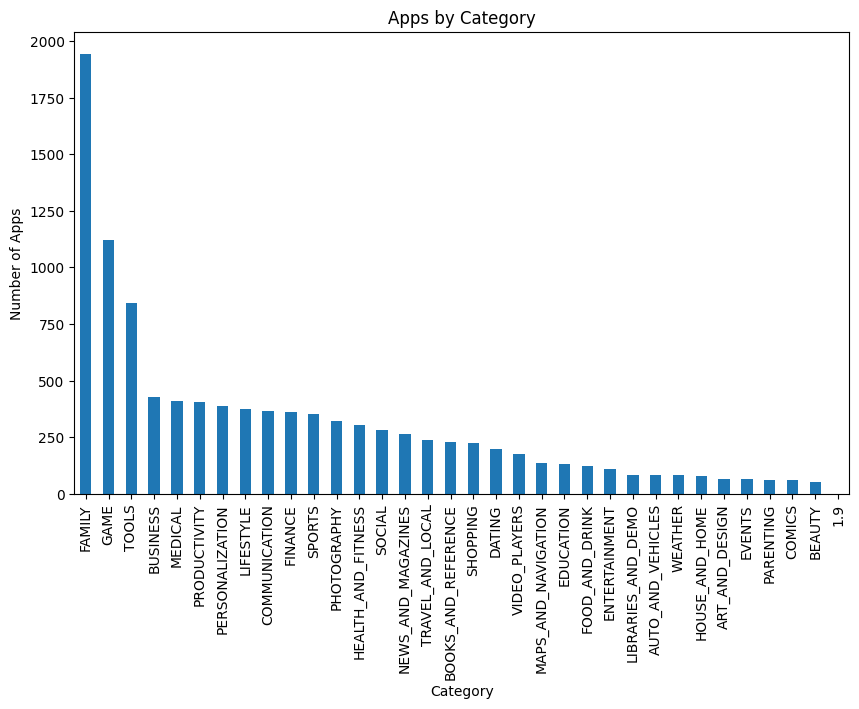

In [ ]:
category=apps["Category"].value_counts()

plt.figure(figsize=(10,6))
category.plot(kind="bar")
plt.title("Apps by Category")
plt.xlabel("Category")
plt.ylabel("Number of Apps")
plt.xticks(rotation=90)
plt.show()

###4.Ratings analysis

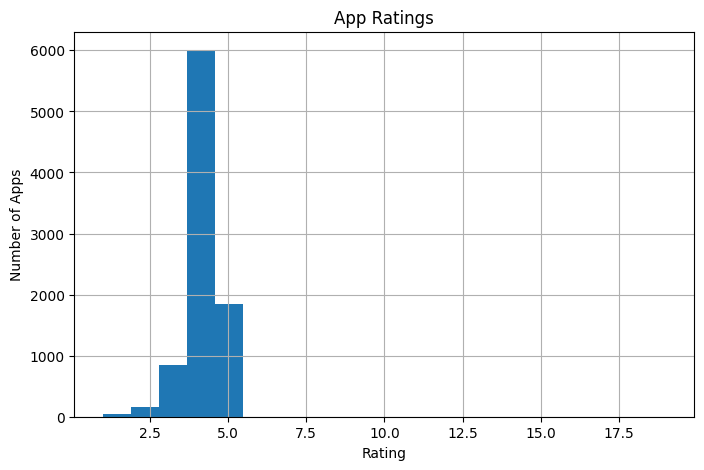

In [ ]:
plt.figure(figsize=(8,5))
apps["Rating"].hist(bins=20)

plt.title("App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")
plt.show()

In [ ]:
#Average rating by category
avg_rating = apps.groupby("Category")["Rating"].mean()

print(avg_rating.sort_values(ascending=False))

Category
1.9                    19.000000
EVENTS                  4.435556
EDUCATION               4.375969
ART_AND_DESIGN          4.358065
BOOKS_AND_REFERENCE     4.347458
PERSONALIZATION         4.333871
PARENTING               4.300000
GAME                    4.281285
BEAUTY                  4.278571
HEALTH_AND_FITNESS      4.261450
SOCIAL                  4.254918
SHOPPING                4.251485
WEATHER                 4.244000
SPORTS                  4.225175
PRODUCTIVITY            4.201796
FAMILY                  4.191153
AUTO_AND_VEHICLES       4.190411
PHOTOGRAPHY             4.182895
MEDICAL                 4.182450
LIBRARIES_AND_DEMO      4.178462
HOUSE_AND_HOME          4.164706
FOOD_AND_DRINK          4.164151
COMICS                  4.155172
COMMUNICATION           4.151466
ENTERTAINMENT           4.136036
NEWS_AND_MAGAZINES      4.128505
FINANCE                 4.127445
BUSINESS                4.102593
LIFESTYLE               4.096066
TRAVEL_AND_LOCAL        4.094146
V

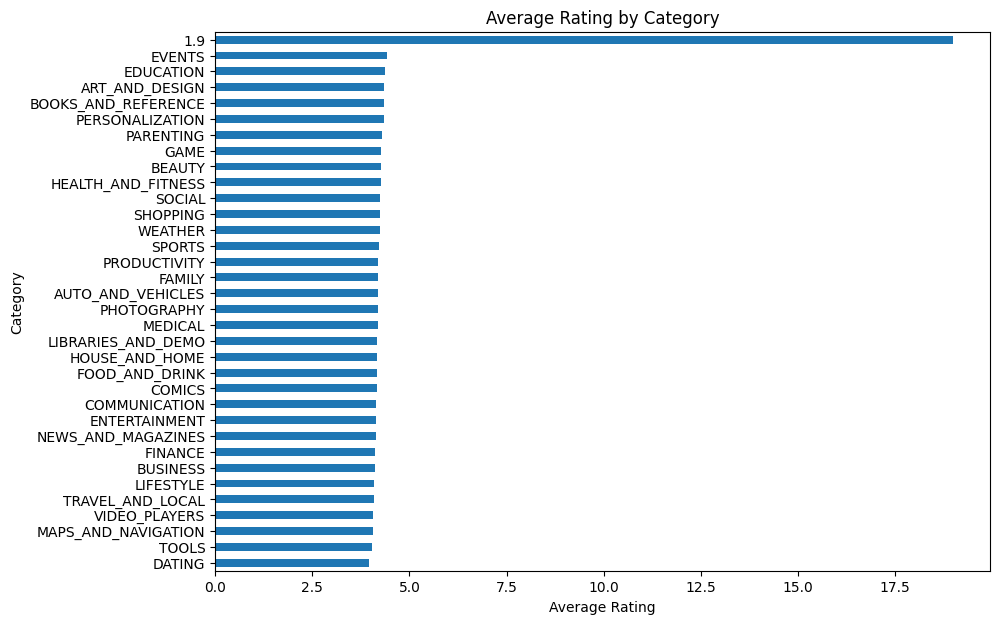

In [ ]:
avg_rating.sort_values().plot(kind="barh", figsize=(10,7))

plt.title("Average Rating by Category")
plt.xlabel("Average Rating")
plt.show()

###5.Size and installs analysis:

In [ ]:
#First convert size to MB
apps["Size"]=apps["Size"].replace("Varies with device",np.nan)
apps["Size"]=apps["Size"].str.replace("M","")
apps["Size"]=pd.to_numeric(apps["Size"],errors="coerce")

In [ ]:
apps["Size"]

,Size
0,19.0
1,14.0
2,8.7
3,25.0
4,2.8
...,...
10836,53.0
10837,3.6
10838,9.5
10839,NaN


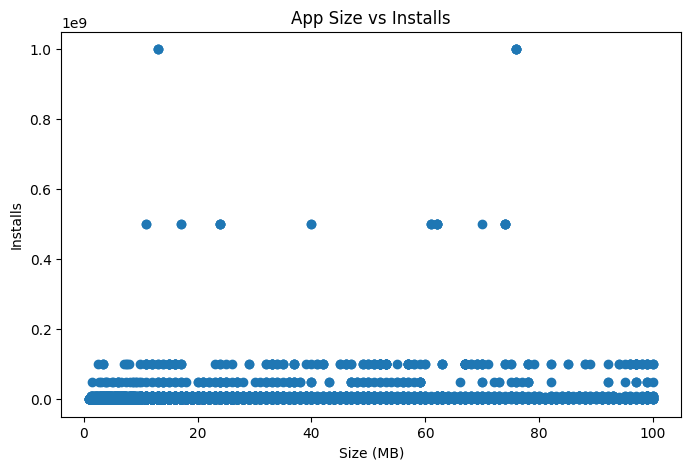

In [ ]:
#plot
plt.figure(figsize=(8,5))

plt.scatter(apps["Size"], apps["Installs"])

plt.title("App Size vs Installs")
plt.xlabel("Size (MB)")
plt.ylabel("Installs")
plt.show()

In [ ]:
print(apps["Size"].corr(apps["Installs"]))

0.16664066758721757


##6.Pricing analysis:

Type
Free    9591
Paid     765
0          1
Name: count, dtype: int64


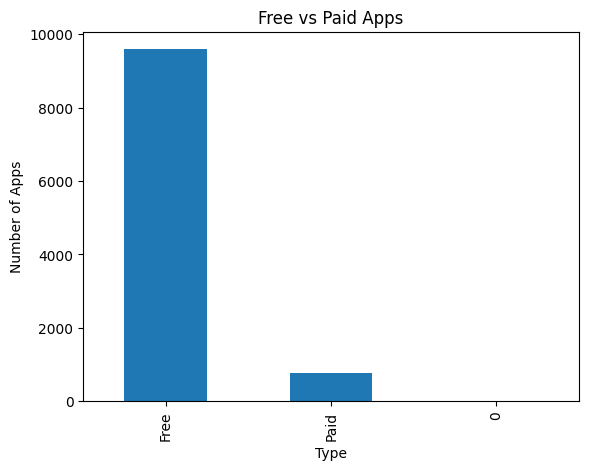

In [ ]:
print(apps["Type"].value_counts())

apps["Type"].value_counts().plot(kind="bar")

plt.title("Free vs Paid Apps")
plt.xlabel("Type")
plt.ylabel("Number of Apps")
plt.show()

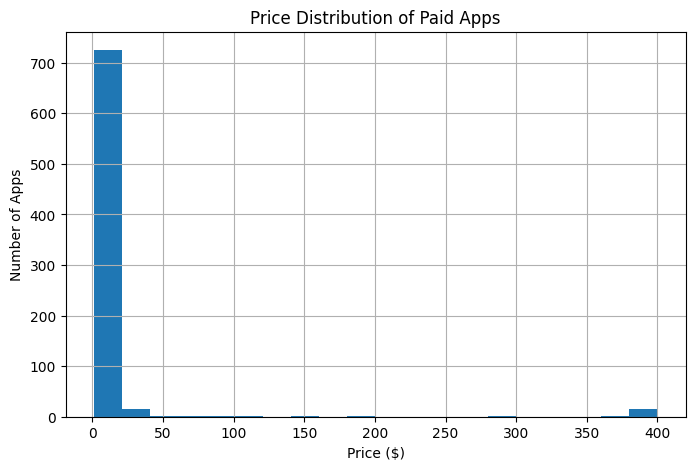

In [ ]:
#price distribution

paid = apps[apps["Type"] == "Paid"]

plt.figure(figsize=(8,5))
paid["Price"].hist(bins=20)

plt.title("Price Distribution of Paid Apps")
plt.xlabel("Price ($)")
plt.ylabel("Number of Apps")
plt.show()

In [ ]:
#estimated revenue

paid["Revenue"] = paid["Price"] * paid["Installs"]

revenue = paid.groupby("Category")["Revenue"].sum()

print(revenue.sort_values(ascending=False))

Category
FAMILY                 1.857803e+08
LIFESTYLE              5.758394e+07
GAME                   4.098764e+07
FINANCE                2.572668e+07
PHOTOGRAPHY            8.942768e+06
MEDICAL                8.456536e+06
PERSONALIZATION        7.786948e+06
TOOLS                  5.464821e+06
SPORTS                 4.706212e+06
PRODUCTIVITY           4.313375e+06
COMMUNICATION          4.247364e+06
WEATHER                4.181380e+06
EDUCATION              2.403980e+06
HEALTH_AND_FITNESS     1.426069e+06
MAPS_AND_NAVIGATION    1.240789e+06
TRAVEL_AND_LOCAL       1.151504e+06
BUSINESS               1.050543e+06
ENTERTAINMENT          7.980000e+05
VIDEO_PLAYERS          3.352900e+05
FOOD_AND_DRINK         2.844000e+05
PARENTING              2.499590e+05
AUTO_AND_VEHICLES      1.001485e+05
BOOKS_AND_REFERENCE    9.022674e+04
DATING                 8.836150e+04
ART_AND_DESIGN         3.184000e+04
SHOPPING               3.014900e+04
NEWS_AND_MAGAZINES     6.445000e+03
SOCIAL             

/tmp/ipykernel_640/362063288.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  paid["Revenue"] = paid["Price"] * paid["Installs"]


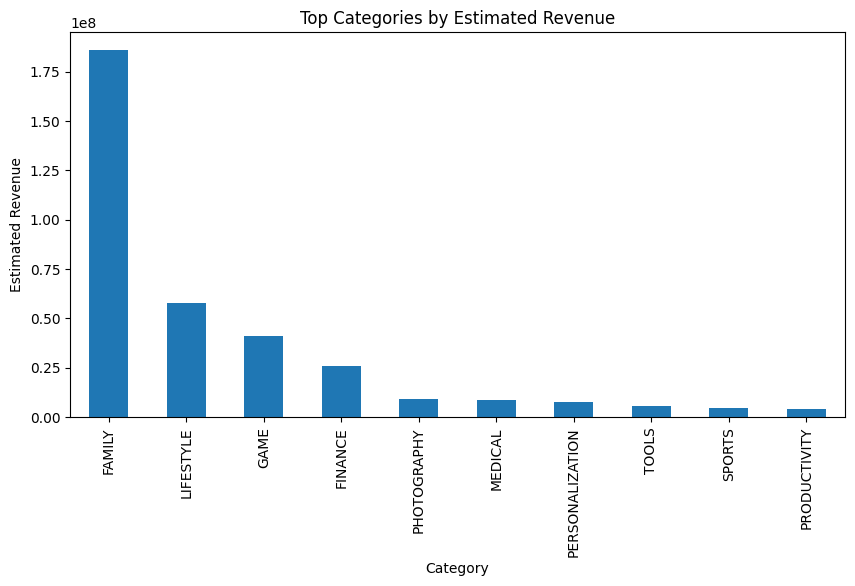

In [ ]:
revenue.sort_values(ascending=False).head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Categories by Estimated Revenue")
plt.xlabel("Category")
plt.ylabel("Estimated Revenue")
plt.show()

##7.Sentiment Analysis


In [ ]:
#remove empty reviews
reviews = reviews.dropna(subset=["Translated_Review"])

In [ ]:
#create a sentiment

def sentiment(text):
    score = TextBlob(text).sentiment.polarity

    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

In [ ]:
reviews["My_Sentiment"] = reviews["Translated_Review"].apply(sentiment)

print(reviews["My_Sentiment"].value_counts())

My_Sentiment
Positive    19014
Negative     6322
Neutral      4356
Name: count, dtype: int64


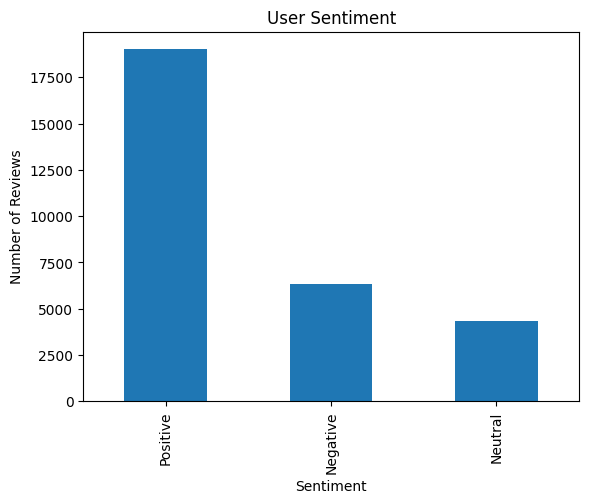

In [ ]:
reviews["My_Sentiment"].value_counts().plot(kind="bar")

plt.title("User Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

##8.Sentiment by category

In [ ]:
reviews = reviews.merge(
    apps[["App", "Category"]],
    on="App",
    how="left"
)

In [ ]:
positive = reviews[reviews["My_Sentiment"] == "Positive"]

print(positive["Category"].value_counts().head(10))

Category
GAME                  5394
FAMILY                2251
HEALTH_AND_FITNESS    1456
PRODUCTIVITY          1107
TRAVEL_AND_LOCAL      1093
PHOTOGRAPHY           1032
TOOLS                 1013
FINANCE               1012
SPORTS                1006
MEDICAL                914
Name: count, dtype: int64


In [ ]:
negative = reviews[reviews["My_Sentiment"] == "Negative"]

print(negative["Category"].value_counts().head(10))

Category
GAME                3485
FAMILY               984
SPORTS               393
TRAVEL_AND_LOCAL     375
FINANCE              350
DATING               322
PRODUCTIVITY         309
SOCIAL               308
PHOTOGRAPHY          305
TOOLS                296
Name: count, dtype: int64


1. Some categories have a much larger number of apps, showing higher competition.

2. Most apps are free, while paid apps are fewer but some categories generate higher estimated revenue.

3. Sentiment analysis shows that user opinions vary across app categories, helping developers identify areas with positive feedback and areas needing improvement.